# Retail Sales Data Analysis

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

In [43]:
import pandas as pd

df = pd.read_csv('retail_sales_dataset.csv')

In [44]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


## Data Cleaning

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [46]:
df.shape

(1000, 9)

In [47]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [48]:
df.duplicated().sum()

np.int64(0)

## Descriptive Statistics

In [49]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [50]:
df['Total Amount'].mean()

np.float64(456.0)

In [51]:
df['Total Amount'].median()

135.0

In [52]:
df['Total Amount'].mode()

,Total Amount
0,50


In [53]:
df['Total Amount'].std()

559.997631555123

## Product Analysis

In [54]:
df.groupby('Product Category')['Total Amount'].sum()

,Total Amount
Product Category,
Beauty,143515
Clothing,155580
Electronics,156905


In [55]:
df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

,Total Amount
Product Category,
Electronics,156905
Clothing,155580
Beauty,143515


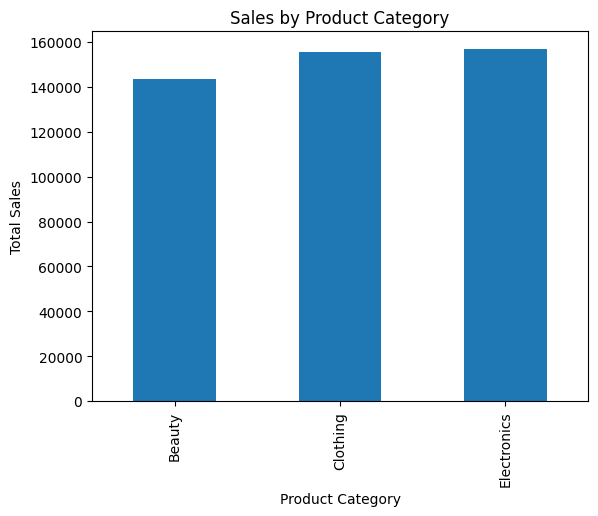

In [56]:
import matplotlib.pyplot as plt

df.groupby('Product Category')['Total Amount'].sum().plot(kind='bar')

plt.title('Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.show()

## Customer Analysis

In [57]:
df.groupby('Gender')['Total Amount'].sum()

,Total Amount
Gender,
Female,232840
Male,223160


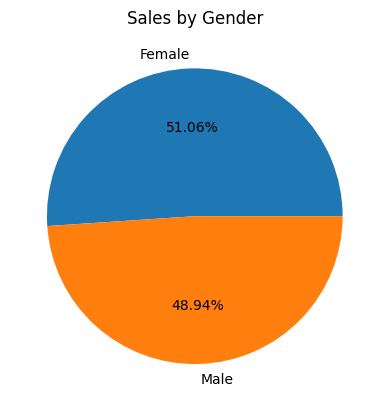

In [58]:
df.groupby('Gender')['Total Amount'].sum().plot(
    kind='pie',
    autopct='%2.2f%%'
)

plt.title('Sales by Gender')
plt.ylabel('')
plt.show()

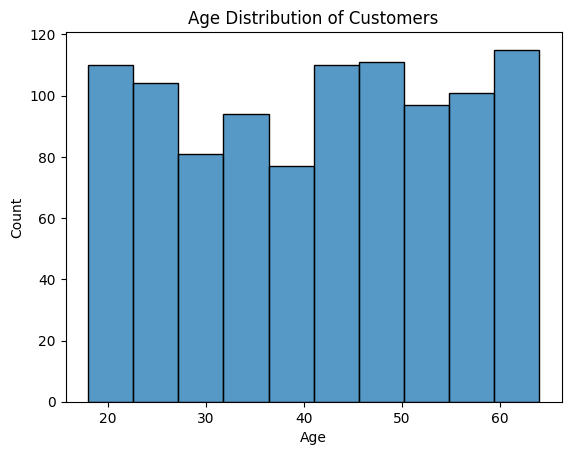

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Age'], bins=10)

plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [60]:
df['Age'].mean()

np.float64(41.392)

In [61]:
df.groupby('Age')['Total Amount'].sum().sort_values(ascending=False)

,Total Amount
Age,
43,17970
34,16785
51,16065
19,14870
26,13980
22,13700
46,13090
21,12585
47,12505


## Time Series Analysis

In [62]:
df['Date'] = pd.to_datetime(df['Date'])

In [63]:
monthly_sales = df.groupby(df['Date'].dt.month)['Total Amount'].sum()
monthly_sales

,Total Amount
Date,
1,36980
2,44060
3,28990
4,33870
5,53150
6,36715
7,35465
8,36960
9,23620


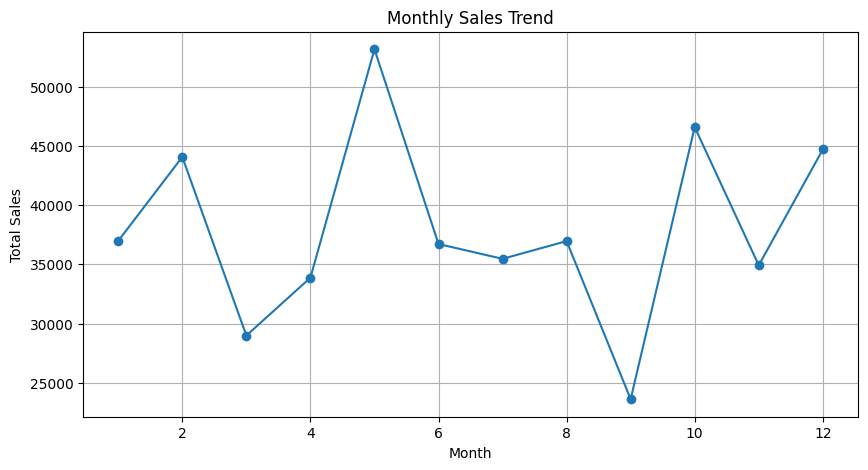

In [64]:
import matplotlib.pyplot as plt

monthly_sales.plot(figsize=(10,5), marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)

plt.show()

In [65]:
print("Highest Sales Month:", monthly_sales.idxmax())
print("Lowest Sales Month:", monthly_sales.idxmin())

Highest Sales Month: 5
Lowest Sales Month: 9


In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

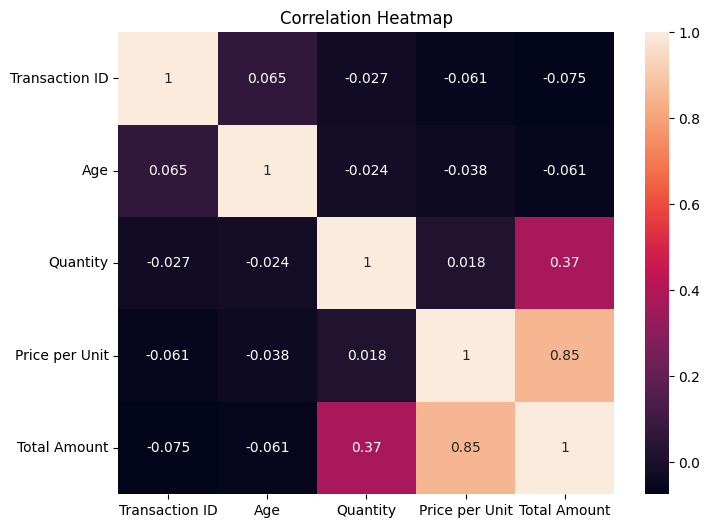

In [67]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()

INSIGHTS


1. Product Category Performance
Electronics generated the highest sales revenue among all product categories.
This indicates strong customer demand for electronic products.
Clothing and Beauty categories contributed comparatively less revenue.
2. Gender-wise Sales
Sales distribution between male and female customers was relatively balanced.
Female customers contributed slightly higher sales than male customers.
Both customer segments are important for business growth.
3. Customer Age Analysis
Customers in the age group around 40–50 years generated significant revenue.
The average customer age is concentrated in the middle-age segment.
This age group appears to be the most active purchasing segment.
4. Monthly Sales Trend
Sales varied across different months.
Certain months recorded noticeably higher revenue, indicating seasonal demand patterns.
Identifying high-performing months can help improve inventory planning.
5. Correlation Analysis
Price per Unit shows a strong positive correlation (0.85) with Total Amount.
Quantity shows a moderate positive correlation (0.37) with Total Amount.
Age has very little correlation with Total Amount, indicating age alone does not strongly influence purchase value.**bold text**

RECOMMENDATIONS

1. Focus on High-Revenue Categories
Increase inventory and promotional activities for Electronics products.
Introduce premium product variants to maximize revenue.
2. Target Middle-Aged Customers
Design marketing campaigns specifically for customers aged 40–50 years.
Offer loyalty programs and personalized recommendations to improve retention.
3. Improve Low-Performing Categories
Launch discounts and bundle offers for Clothing and Beauty products.
Analyze customer preferences to improve product assortment.
4. Leverage Seasonal Demand
Prepare additional stock before high-sales months.
Run targeted promotions during peak demand periods to maximize revenue.
5. Increase Average Order Value
Since Price per Unit strongly influences Total Amount, promote premium products and upselling strategies.
Encourage customers to purchase higher-value products through special offers.
6. Data-Driven Decision Making
Continuously monitor sales trends, customer behavior, and product performance using EDA dashboards.
Use insights to optimize inventory management and marketing strategies.